In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
final_cleaned_df=pd.read_csv(r"D:\Data Analyst\EXCEL\supplychain\cleaned\final_cleaned.csv")

In [4]:
eda_data=final_cleaned_df.copy()

# Structure of the Notebook

1. Introduction
2. Dataset Overview
3. Univariate Analysis
4. Bivariate Analysis
5. Multivariate Analysis
6. Time Series Analysis
7. Supply Chain Analysis
8. Customer Analysis
9. Product Analysis
10. Inventory Analysis
11. Shipping Analysis
12. Profitability Analysis
13. Summary of Insights

### Remove unwanted columns for EDA

In [5]:
eda_data.columns

Index(['Unnamed: 0', 'order_line_id', 'order_id', 'date_id', 'order_date',
       'customer_id', 'product_id', 'category', 'seller_id', 'seller_rating',
       'location_id_x', 'delivery_person_id', 'payment_id', 'campaign_id',
       'fulfillment_id', 'quantity', 'unit_price', 'discount_percentage',
       'tax_percentage', 'shipping_fee', 'expected_delivery_date',
       'actual_delivery_date', 'delivery_rating', 'order_status',
       'return_flag', 'refund_amount', 'return_date', 'customer_rating',
       'review_text', 'sentiment_score', 'delivery_delay_days',
       'delivery_sla_days', 'gross_amount', 'discount_amount', 'tax_amount',
       'net_amount', 'product_name', 'brand', 'first_name', 'email_x',
       'phone_number_x', 'marital_status', 'payment_method',
       'payment_provider', 'description', 'seller_name', 'email_y',
       'phone_number_y', 'join_date', 'location_id_y', 'rating',
       'category_focus', 'bank_name', 'bank_account_number', 'ifsc_code',
       'deli

In [6]:
df2=eda_data[['order_line_id','order_date','customer_id', 'product_id', 'category','seller_id', 'seller_rating','location_id_x','delivery_person_id','payment_id', 'campaign_id','fulfillment_id','quantity', 'unit_price', 'discount_percentage', 'tax_percentage', 'shipping_fee', 'expected_delivery_date', 'actual_delivery_date', 'delivery_rating', 'order_status', 'return_flag', 'refund_amount', 'return_date', 'customer_rating', 'review_text', 'sentiment_score', 'delivery_delay_days', 'delivery_sla_days', 'gross_amount', 'discount_amount', 'tax_amount', 'net_amount', 'product_name', 'brand', 'first_name', 'marital_status', 'payment_method', 'payment_provider', 'seller_name', 'delivery_person_name', 'employment_type', 'vehicle_type', 'state', 'city', 'postal_code', 'region']]


### Data inspection


- Shape	Number of rows and columns
- Columns	Available fields
- Head	Sample records
- Info	Data types and null values
- Describe	Numeric summary
- Duplicates	Duplicate records
- Missing Values	Null counts
- Unique Values	Category counts

In [7]:
df2.shape

(790732, 47)

In [8]:
df2.head()

,order_line_id,order_date,customer_id,product_id,category,seller_id,seller_rating,location_id_x,delivery_person_id,payment_id,...,payment_method,payment_provider,seller_name,delivery_person_name,employment_type,vehicle_type,state,city,postal_code,region
0,OL00000001,2026-02-20,CUST009513,PROD000763,Baby,SELL2379,4.6,LOC0010,DEL01094,PAY005,...,Debit Card,Mastercard,"Virk, Kamdar and Kakar",Bhamini Acharya,Full-Time,Van,Karnataka,Bengaluru,843810,South
1,OL00000002,2025-12-02,CUST003412,PROD000142,Clothing,SELL2964,4.0,LOC0053,DEL01927,PAY004,...,Debit Card,Visa,"Chauhan, Bahl and Sem",Emir Roy,Contract,Bike,Madhya Pradesh,Bhopal,406047,Central
2,OL00000003,2025-04-03,CUST065509,PROD001194,Gaming,SELL2485,3.9,LOC0095,DEL00300,PAY009,...,UPI,Paytm,Loke-Gupta,Akarsh Bala,Full-Time,EV Bike,Delhi,Dwarka,246344,North
3,OL00000004,2025-06-01,CUST070677,PROD000221,Home,SELL4121,4.0,LOC0038,DEL02152,PAY004,...,Debit Card,Visa,Sengupta-D’Alia,Urvi Sabharwal,Contract,Scooter,West Bengal,Kharagpur,705775,East
4,OL00000005,2025-10-25,CUST017845,PROD000806,Pets,SELL3183,4.5,LOC0109,DEL03896,PAY012,...,Wallet,Amazon Pay,Varghese Group,Vivaan Warrior,Full-Time,EV Bike,Haryana,Faridabad,744789,North


In [9]:
df2.describe()

,seller_rating,quantity,unit_price,discount_percentage,tax_percentage,shipping_fee,delivery_rating,refund_amount,customer_rating,sentiment_score,delivery_delay_days,delivery_sla_days,gross_amount,discount_amount,tax_amount,net_amount,postal_code
count,790732.000000,790732.000000,7.907320e+05,790732.000000,790732.0,790732.000000,790732.000000,790732.000000,790732.000000,790732.000000,790732.000000,790732.000000,7.907320e+05,790732.000000,790732.000000,7.907320e+05,790732.000000
mean,3.933004,3.001877,1.443109e+04,4.998254,5.0,116.332926,3.999889,-15.148007,3.717985,0.379188,0.450298,2.663600,4.322148e+04,2156.610857,2161.074214,4.334228e+04,525987.900046
std,0.888860,1.413882,5.030919e+04,2.886348,0.0,72.308419,0.835484,47.047367,0.887309,0.455638,0.668581,1.698761,1.670267e+05,9589.267398,8351.335561,1.672835e+05,259082.111332
min,1.000000,1.000000,2.000000e+01,0.000000,5.0,46.270000,1.000000,-215.790000,1.000000,-1.000000,0.000000,1.000000,2.000000e+01,0.000000,1.000000,6.536000e+01,113106.000000
25%,3.700000,2.000000,6.990000e+02,2.500000,5.0,46.270000,3.700000,0.000000,3.300000,0.180000,0.000000,1.000000,1.598000e+03,56.780100,79.900000,1.743270e+03,273826.000000
50%,4.100000,3.000000,1.999000e+03,4.990000,5.0,86.640000,4.200000,0.000000,3.800000,0.450000,0.000000,2.000000,5.397000e+03,220.310400,269.850000,5.480865e+03,522344.000000
75%,4.500000,4.000000,8.499000e+03,7.500000,5.0,215.790000,4.600000,0.000000,4.400000,0.730000,1.000000,5.000000,2.249500e+04,974.610000,1124.750000,2.240403e+04,755367.000000
max,5.000000,5.000000,1.150000e+06,10.000000,5.0,215.790000,5.000000,0.000000,5.000000,1.000000,2.000000,5.000000,5.750000e+06,572700.000000,287500.000000,6.031796e+06,989497.000000


In [10]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 790732 entries, 0 to 790731
Data columns (total 47 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_line_id           790732 non-null  object 
 1   order_date              790732 non-null  object 
 2   customer_id             790732 non-null  object 
 3   product_id              790732 non-null  object 
 4   category                790732 non-null  object 
 5   seller_id               790732 non-null  object 
 6   seller_rating           790732 non-null  float64
 7   location_id_x           790732 non-null  object 
 8   delivery_person_id      790732 non-null  object 
 9   payment_id              790732 non-null  object 
 10  campaign_id             790732 non-null  object 
 11  fulfillment_id          790732 non-null  object 
 12  quantity                790732 non-null  int64  
 13  unit_price              790732 non-null  int64  
 14  discount_percentage 

In [11]:
df2.columns

Index(['order_line_id', 'order_date', 'customer_id', 'product_id', 'category',
       'seller_id', 'seller_rating', 'location_id_x', 'delivery_person_id',
       'payment_id', 'campaign_id', 'fulfillment_id', 'quantity', 'unit_price',
       'discount_percentage', 'tax_percentage', 'shipping_fee',
       'expected_delivery_date', 'actual_delivery_date', 'delivery_rating',
       'order_status', 'return_flag', 'refund_amount', 'return_date',
       'customer_rating', 'review_text', 'sentiment_score',
       'delivery_delay_days', 'delivery_sla_days', 'gross_amount',
       'discount_amount', 'tax_amount', 'net_amount', 'product_name', 'brand',
       'first_name', 'marital_status', 'payment_method', 'payment_provider',
       'seller_name', 'delivery_person_name', 'employment_type',
       'vehicle_type', 'state', 'city', 'postal_code', 'region'],
      dtype='object')

In [12]:
df2.loc[:, 'order_date'] = pd.to_datetime(df2['order_date'])

# Business Question

### What are the total orders placed

In [13]:

Total_orders=df2['order_line_id'].drop_duplicates().count()
Total_orders

np.int64(790732)

### How many customers placed orders

In [14]:
# Customers
Customers=df2['customer_id'].drop_duplicates().count()
Customers

np.int64(90818)

### How many sellers are there

In [15]:
# Sellers
Sellers=df2['seller_id'].drop_duplicates().count()
Sellers

np.int64(4563)

### How many orders placed ever_day

In [16]:
#Transactions per date
Transactions = (
    df2.groupby('order_date')['payment_id']
       .count()
       .reset_index(name='transactions')
       .sort_values('order_date', ascending=False)
)

Transactions

,order_date,transactions
365,2026-04-02,2195
364,2026-04-01,2150
363,2026-03-31,2200
362,2026-03-30,2216
361,2026-03-29,2135
...,...,...
4,2025-04-06,2173
3,2025-04-05,2156
2,2025-04-04,2158
1,2025-04-03,2098


# Sales Analysis

### How much revenue did the company generate?

In [17]:
Revenue=round(sum(df2['net_amount']),2)
Revenue

34272128208.32

### Monthly Revenue Trend

In [18]:
df2=df2.copy()

In [19]:

df2['order_date']=pd.to_datetime(df2['order_date'])

In [20]:
df2['order_date'].dtype

dtype('<M8[ns]')

In [21]:
Monthly_revenue = (
    df2.groupby(df2['order_date'].dt.to_period('M'))['net_amount']
       .sum()
       .reset_index(name='monthly_revenue')
)
Monthly_revenue

,order_date,monthly_revenue
0,2025-04,2.842805e+09
1,2025-05,2.878418e+09
2,2025-06,2.797245e+09
3,2025-07,2.892562e+09
4,2025-08,2.887323e+09
5,2025-09,2.735873e+09
6,2025-10,2.804357e+09
7,2025-11,2.840193e+09
8,2025-12,2.871660e+09
9,2026-01,2.919455e+09


In [22]:
Monthly_revenue['order_date'] = Monthly_revenue['order_date'].dt.to_timestamp()

### Removed incomplete months

In [23]:
#Remove incomplete months

Monthly_revenue = Monthly_revenue[
    Monthly_revenue['order_date'] < pd.Timestamp('2026-04-01')
]

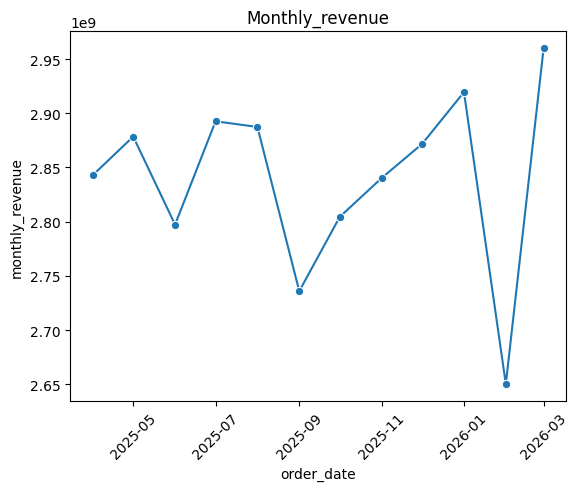

In [24]:
plt.title("Monthly_revenue")
sns.lineplot(data=Monthly_revenue, x='order_date', y='monthly_revenue', marker='o')
plt.xticks(rotation=45)
plt.show()

### Top 10 Revenue Generating Products

In [25]:
top_10_products = (
    df2.groupby(['product_id', 'product_name'])['net_amount']
       .sum()
       .reset_index()
       .sort_values('net_amount', ascending=False)
       .head(10)
)

top_10_products[['product_name','net_amount']]

,product_name,net_amount
970,Submariner Date Automatic,2.121628e+09
971,Speedmaster Moonwatch Professional,1.093409e+09
1249,Sony VPL-FHZ60 6000L Laser,8.971965e+08
22,Z8 Mirrorless,6.495340e+08
1115,Nord Stage 3 88 Key,6.207335e+08
16,MSI Raider GE78 HX,4.837243e+08
1240,PowerLite L400U Laser WUXGA,4.811351e+08
20,EOS R6 Mark II,4.765599e+08
1101,Les Paul Standard 60s,4.713287e+08
1247,LG CineBeam HU710PW 4K UST,4.542683e+08


In [26]:
top_10_products

,product_id,product_name,net_amount
970,PROD000971,Submariner Date Automatic,2.121628e+09
971,PROD000972,Speedmaster Moonwatch Professional,1.093409e+09
1249,PROD001250,Sony VPL-FHZ60 6000L Laser,8.971965e+08
22,PROD000023,Z8 Mirrorless,6.495340e+08
1115,PROD001116,Nord Stage 3 88 Key,6.207335e+08
16,PROD000017,MSI Raider GE78 HX,4.837243e+08
1240,PROD001241,PowerLite L400U Laser WUXGA,4.811351e+08
20,PROD000021,EOS R6 Mark II,4.765599e+08
1101,PROD001102,Les Paul Standard 60s,4.713287e+08
1247,PROD001248,LG CineBeam HU710PW 4K UST,4.542683e+08


In [27]:
top = (
    df2[['product_id', 'product_name', 'unit_price']]
    .sort_values('unit_price', ascending=False)
    .drop_duplicates(subset='product_id')
    .head(10)
)

top

,product_id,product_name,unit_price
156012,PROD000971,Submariner Date Automatic,1150000
415738,PROD000972,Speedmaster Moonwatch Professional,580000
624501,PROD001250,Sony VPL-FHZ60 6000L Laser,499999
790725,PROD001116,Nord Stage 3 88 Key,349999
477853,PROD000023,Z8 Mirrorless,349990
63204,PROD001248,LG CineBeam HU710PW 4K UST,249999
78939,PROD001102,Les Paul Standard 60s,249999
555141,PROD001241,PowerLite L400U Laser WUXGA,249999
156119,PROD000017,MSI Raider GE78 HX,249990
35,PROD000021,EOS R6 Mark II,239990


### Top Categories by Revenue

In [28]:
top_categories=(
    df2.groupby(['category'])['net_amount']
       .sum()
       .reset_index()
       .sort_values('net_amount', ascending=False)
       .head(10)
)

top_categories

,category,net_amount
6,Electronics,1.222135e+10
13,Music & Instruments,5.447600e+09
12,Jewellery,5.276126e+09
14,Office Supplies,3.746905e+09
8,Gaming,1.445363e+09
11,Home,1.150213e+09
7,Footwear,7.801014e+08
2,Bags & Luggage,7.534758e+08
16,Sports,6.198205e+08
0,Automotive,5.527822e+08


In [29]:
df2['Month'] = df2['order_date'].dt.to_period('M')
df2 = df2[df2['order_date'] < '2026-04-01']

monthly_sales = (
    df2.groupby('Month')['net_amount']
    .sum()
    .reset_index()
)

monthly_sales['MoM_Growth_%'] = (
    monthly_sales['net_amount'].pct_change() * 100
)

round(monthly_sales,2)

,Month,net_amount,MoM_Growth_%
0,2025-04,2.842805e+09,NaN
1,2025-05,2.878418e+09,1.25
2,2025-06,2.797245e+09,-2.82
3,2025-07,2.892562e+09,3.41
4,2025-08,2.887323e+09,-0.18
5,2025-09,2.735873e+09,-5.25
6,2025-10,2.804357e+09,2.50
7,2025-11,2.840193e+09,1.28
8,2025-12,2.871660e+09,1.11
9,2026-01,2.919455e+09,1.66


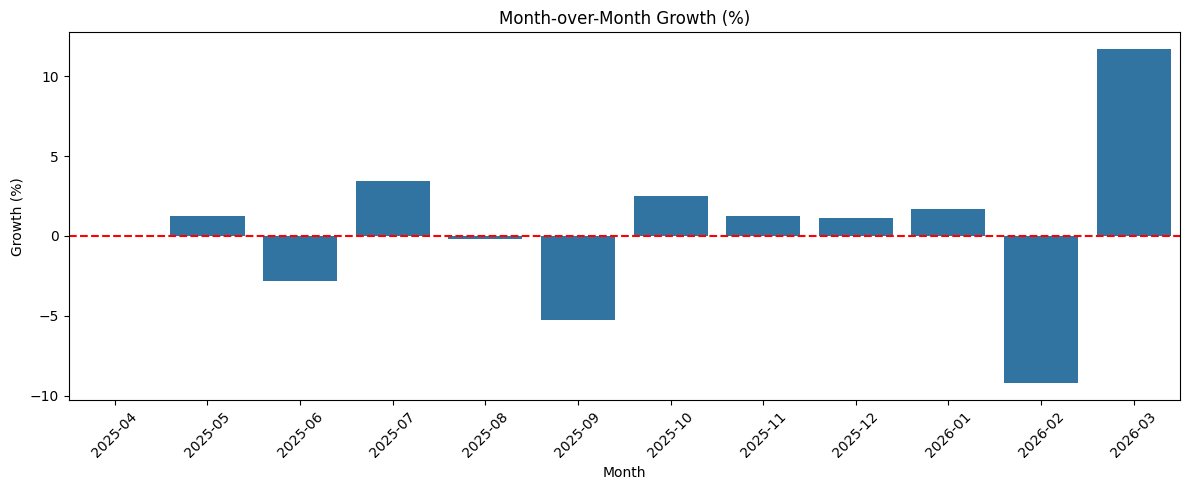

In [30]:
plt.figure(figsize=(12,5))

sns.barplot(
    data=monthly_sales,
    x='Month',
    y='MoM_Growth_%'
)

plt.axhline(0, color='red', linestyle='--')
plt.title('Month-over-Month Growth (%)')
plt.xlabel('Month')
plt.ylabel('Growth (%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Average Order Value (AOV)

In [31]:
aov = df2['net_amount'].sum() / df2['order_line_id'].nunique()

print(aov)

43337.457991586845


### Revenue Contribution Percentage by Category

In [32]:
category_revenue = (
    df2.groupby('category')['net_amount']
       .sum()
       .sort_values(ascending=False)
       .reset_index()
)

category_revenue

,category,net_amount
0,Electronics,1.214500e+10
1,Music & Instruments,5.419267e+09
2,Jewellery,5.256486e+09
3,Office Supplies,3.720655e+09
4,Gaming,1.438995e+09
5,Home,1.143510e+09
6,Footwear,7.762050e+08
7,Bags & Luggage,7.486150e+08
8,Sports,6.156641e+08
9,Automotive,5.497761e+08


In [33]:
category_revenue['Revenue_Contribution_%'] = (
    category_revenue['net_amount']
    / category_revenue['net_amount'].sum()
    * 100
).round(2)

category_revenue

,category,net_amount,Revenue_Contribution_%
0,Electronics,1.214500e+10,35.64
1,Music & Instruments,5.419267e+09,15.90
2,Jewellery,5.256486e+09,15.42
3,Office Supplies,3.720655e+09,10.92
4,Gaming,1.438995e+09,4.22
5,Home,1.143510e+09,3.36
6,Footwear,7.762050e+08,2.28
7,Bags & Luggage,7.486150e+08,2.20
8,Sports,6.156641e+08,1.81
9,Automotive,5.497761e+08,1.61


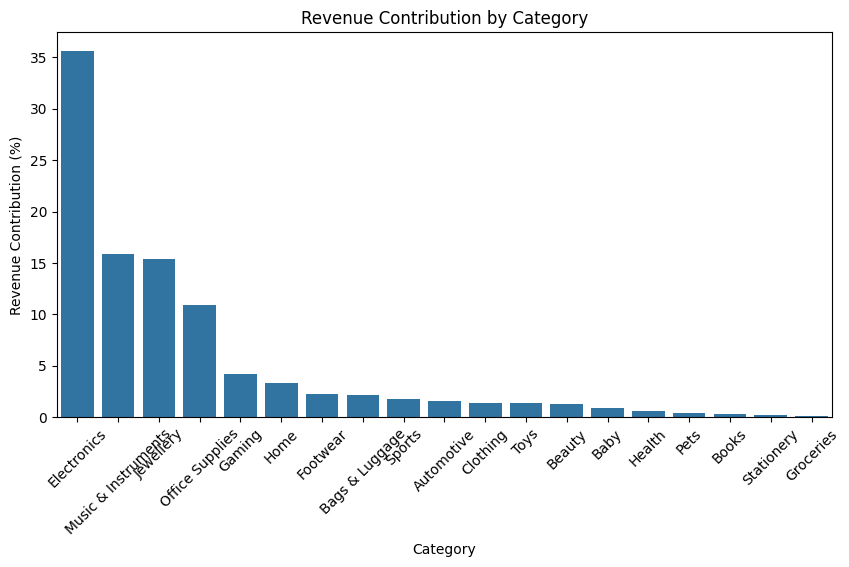

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.barplot(
    data=category_revenue,
    x='category',
    y='Revenue_Contribution_%'
)

plt.title('Revenue Contribution by Category')
plt.xlabel('Category')
plt.ylabel('Revenue Contribution (%)')
plt.xticks(rotation=45)

plt.show()

In [35]:
low_products = (
    df2.groupby(['product_id', 'product_name'])['order_line_id']
       .nunique()
       .sort_values()
       .reset_index(name='Total_Orders')
       .head(10)
)

low_products

,product_id,product_name,Total_Orders
0,PROD000266,Retinol Night Serum,548
1,PROD000212,Instant Pot Duo 6L,557
2,PROD000107,Graphic Tee Round Neck,558
3,PROD000748,Teething Biscuits Vanilla 130g,560
4,PROD001231,Steel Filing Cabinet 2-Drawer,560
5,PROD000968,Rudraksha Bracelet 8mm,561
6,PROD000141,Woollen Muffler,563
7,PROD000483,Baby Musical Mobile,563
8,PROD000183,Queen Size Bed with Storage,563
9,PROD000048,boAt Enigma X600,566


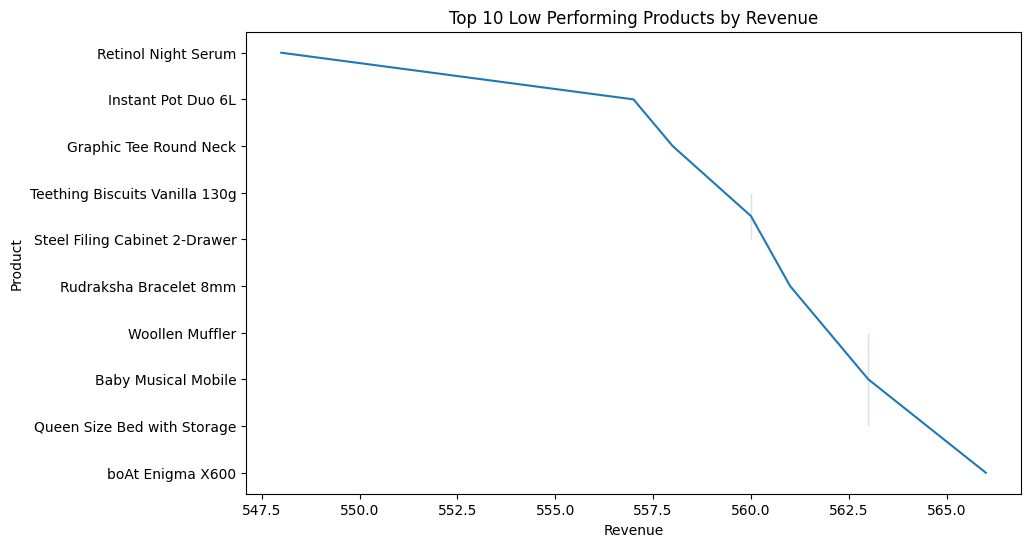

In [36]:


plt.figure(figsize=(10, 6))

sns.lineplot(
    data=low_products,
    x='Total_Orders',
    y='product_name',
    markers='o'
)

plt.title('Top 10 Low Performing Products by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product')
plt.show()

# Customer Analytics 

### How much money does each customer generate?

In [37]:
customers_spent =(
    round(df2.groupby(['customer_id','first_name'])['net_amount']
       .sum(),2)
       .reset_index(name='Total_Spent')
       .sort_values('Total_Spent', ascending=False)
       .head(10)
)

round(customers_spent,2)

,customer_id,first_name,Total_Spent
9880,CUST009883,hazel,13130495.56
56379,CUST056391,purab,8721002.94
8655,CUST008658,nirvi,8042956.05
29687,CUST029691,kanav,7420275.08
86116,CUST086131,indranil,7304032.45
53536,CUST053546,rati,7022876.67
54944,CUST054956,ishita,7021091.44
38058,CUST038068,divij,6965017.15
1268,CUST001269,abram,6955558.41
51026,CUST051036,gatik,6909972.33


# Product Analytics

### Best Selling Products by Quantity

In [38]:
Best_selling_products=(round(df2.groupby(['product_id','product_name'])['quantity'].sum(),2)
                       .reset_index(name="best")
                       .sort_values('best',ascending=False)
                       .head(10))
Best_selling_products


,product_id,product_name,best
1049,PROD001050,Sports Backpack Gymbag 20L,2179
13,PROD000014,HP Spectre x360 14,2154
343,PROD000344,Zero to One,2099
1097,PROD001098,Cable Organizer Roll Pouch,2097
341,PROD000342,Thinking Fast and Slow,2093
109,PROD000110,Linen Kurta,2089
408,PROD000409,101 Dalmatians Illustrated,2084
968,PROD000969,Adjustable Crystal Bangle,2082
523,PROD000524,Ticket to Ride India,2081
834,PROD000835,Eye Drops Pet Antibiotic,2077


### Top Product Per Category

In [39]:
Top_product_per_category=(df2.groupby('category',)['quantity']
                          .sum()
                          .reset_index(name="product_count")
                          .sort_values('product_count',ascending=False)
                          .head(10))
Top_product_per_category

,category,product_count
6,Electronics,188361
5,Clothing,149749
4,Books,149697
9,Groceries,149059
11,Home,148230
3,Beauty,131384
12,Jewellery,131127
16,Sports,130809
1,Baby,130802
18,Toys,130394




# Seller Analysis

### Top Sellers By Revenue


In [40]:
top_seller=(round(df2.groupby(['seller_id','seller_name'])['net_amount'].sum(),2)
            .reset_index(name='seller_revenue')
            .sort_values('seller_revenue',ascending=False)
            .head(10))
top_seller

,seller_id,seller_name,seller_revenue
4127,SELL4128,Chokshi PLC,57433320.11
4416,SELL4417,Shan Ltd,54836797.38
4116,SELL4117,"Keer, Tata and Krishna",54784427.48
2602,SELL2603,Kunda-Kashyap,54564685.23
3275,SELL3276,"Sane, Baria and Mand",54178887.12
3627,SELL3628,Dhawan Inc,53901426.34
3589,SELL3590,"Mandal, Ram and Bhargava",53839238.75
3994,SELL3995,Dugar-Jayaraman,53716005.43
1085,SELL1086,Thakkar-Hegde,53653427.77
3855,SELL3856,"Sarkar, Mann and Babu",53348362.48


###  Top Sellers By Revenue

In [41]:
seller_rating=(round(df2.groupby('customer_rating')['net_amount']
               .sum(),2)
               .reset_index(name="revenue")
               .sort_values('revenue',ascending=False)
               .head(10))
seller_rating

,customer_rating,revenue
27,3.7,3.116448e+09
22,3.2,1.431671e+09
37,4.7,1.428472e+09
32,4.2,1.426629e+09
26,3.6,1.418037e+09
24,3.4,1.417394e+09
31,4.1,1.413617e+09
21,3.1,1.407015e+09
30,4.0,1.406905e+09
23,3.3,1.397266e+09


In [42]:
df2.head()

,order_line_id,order_date,customer_id,product_id,category,seller_id,seller_rating,location_id_x,delivery_person_id,payment_id,...,payment_provider,seller_name,delivery_person_name,employment_type,vehicle_type,state,city,postal_code,region,Month
0,OL00000001,2026-02-20,CUST009513,PROD000763,Baby,SELL2379,4.6,LOC0010,DEL01094,PAY005,...,Mastercard,"Virk, Kamdar and Kakar",Bhamini Acharya,Full-Time,Van,Karnataka,Bengaluru,843810,South,2026-02
1,OL00000002,2025-12-02,CUST003412,PROD000142,Clothing,SELL2964,4.0,LOC0053,DEL01927,PAY004,...,Visa,"Chauhan, Bahl and Sem",Emir Roy,Contract,Bike,Madhya Pradesh,Bhopal,406047,Central,2025-12
2,OL00000003,2025-04-03,CUST065509,PROD001194,Gaming,SELL2485,3.9,LOC0095,DEL00300,PAY009,...,Paytm,Loke-Gupta,Akarsh Bala,Full-Time,EV Bike,Delhi,Dwarka,246344,North,2025-04
3,OL00000004,2025-06-01,CUST070677,PROD000221,Home,SELL4121,4.0,LOC0038,DEL02152,PAY004,...,Visa,Sengupta-D’Alia,Urvi Sabharwal,Contract,Scooter,West Bengal,Kharagpur,705775,East,2025-06
4,OL00000005,2025-10-25,CUST017845,PROD000806,Pets,SELL3183,4.5,LOC0109,DEL03896,PAY012,...,Amazon Pay,Varghese Group,Vivaan Warrior,Full-Time,EV Bike,Haryana,Faridabad,744789,North,2025-10


### Sellers With Low Ratings

In [43]:
seller_low_rating = (round(
    df2.groupby('seller_id')['seller_rating']
       .mean(),2)
       .reset_index()
       .sort_values('seller_rating',ascending=True)
       .head(10)
)

seller_low_rating

,seller_id,seller_rating
4514,SELL4515,3.65
3962,SELL3963,3.66
2056,SELL2057,3.67
130,SELL0131,3.67
3156,SELL3157,3.69
2803,SELL2804,3.70
3334,SELL3335,3.70
779,SELL0780,3.71
1299,SELL1300,3.71
150,SELL0151,3.71


#  Return Analysis

### Overall Return

In [44]:
returns=df2['return_date'].count()
returns

np.int64(102503)

### Overall Return Rate

In [45]:
total_orders = df2['order_line_id'].nunique()

returned_orders = df2[df2['return_date'].notna()]['order_line_id'].nunique()

return_rate = (returned_orders / total_orders) * 100

print(return_rate)

13.034676310773193


### Top Returned Products

In [46]:
top_products_returned=(df2.groupby(['product_id','product_name'])['return_date']
                       .count()
                       .reset_index(name="return")
                       .sort_values('return',ascending=False)
                       .head(10))
top_products_returned

,product_id,product_name,return
1226,PROD001227,Lumbar Support Chair,112
552,PROD000553,Car Vacuum Cleaner Wet & Dry,111
197,PROD000198,Throw Cushions Set of 5,109
221,PROD000222,Plant Pots Set of 5 Ceramic,108
569,PROD000570,Windshield Flyscreen Dark,106
787,PROD000788,Hooded Towel + Washcloth Set,105
390,PROD000391,JEE Advanced Previous Papers,105
640,PROD000641,Full Cream Milk 1L,105
1044,PROD001045,Anti-Theft Backpack Urban,104
907,PROD000908,Crepe Paper Rolls 12-Color,104


### Customers With Highest Returns

In [47]:
top_products_returned=(df2.groupby(['customer_id','first_name'])['return_date']
                       .count()
                       .reset_index(name="return")
                       .sort_values('return',ascending=False)
                       .head(10))
top_products_returned

,customer_id,first_name,return
11009,CUST011012,advik,8
81828,CUST081841,pranay,8
8844,CUST008847,pihu,7
11187,CUST011190,vidur,7
26092,CUST026096,priyansh,7
30604,CUST030608,anika,7
29851,CUST029855,jiya,7
38346,CUST038356,kartik,7
51138,CUST051148,kashvi,7
45103,CUST045113,neysa,7


#  Delivery Analytics

### Average Delivery Delay

In [48]:
Total_orders

np.int64(790732)

### Delay_orders

In [49]:
delay_orders=df2['delivery_delay_days'].count()
delay_orders

np.int64(786387)

### Average Delivery Delay

In [50]:
avg_delivery_delay = round(df2['delivery_delay_days'].mean(), 2)

print(avg_delivery_delay)

0.45


### Late Delivery Percentage

In [51]:
delay_rate = (round(
    (df2['delivery_delay_days'] > 0).mean() * 100
))

delay_rate

35

In [52]:
Total_orders = df2['order_line_id'].nunique()

late_delivery_rate = (
    (df2['delivery_delay_days'] > 0).sum()
    / Total_orders
    * 100
)

round(late_delivery_rate, 2)

np.float64(35.05)

### Best Delivery Locations

In [53]:
Best_Delivery_Locations=(df2.groupby(['location_id_x','city'])['delivery_delay_days'].sum().reset_index(name="no_of_delays").sort_values('no_of_delays',ascending=True).head(10))
Best_Delivery_Locations

,location_id_x,city,no_of_delays
47,LOC0048,Udaipur,2763
16,LOC0017,Chennai,2873
69,LOC0070,Karimnagar,2877
41,LOC0042,Rajkot,2899
38,LOC0039,Ahmedabad,2902
112,LOC0113,Rohtak,2911
89,LOC0090,Patiala,2922
93,LOC0094,New Delhi,2927
57,LOC0058,Sagar,2946
10,LOC0011,Mysuru,2948


In [54]:
df2.head()

,order_line_id,order_date,customer_id,product_id,category,seller_id,seller_rating,location_id_x,delivery_person_id,payment_id,...,payment_provider,seller_name,delivery_person_name,employment_type,vehicle_type,state,city,postal_code,region,Month
0,OL00000001,2026-02-20,CUST009513,PROD000763,Baby,SELL2379,4.6,LOC0010,DEL01094,PAY005,...,Mastercard,"Virk, Kamdar and Kakar",Bhamini Acharya,Full-Time,Van,Karnataka,Bengaluru,843810,South,2026-02
1,OL00000002,2025-12-02,CUST003412,PROD000142,Clothing,SELL2964,4.0,LOC0053,DEL01927,PAY004,...,Visa,"Chauhan, Bahl and Sem",Emir Roy,Contract,Bike,Madhya Pradesh,Bhopal,406047,Central,2025-12
2,OL00000003,2025-04-03,CUST065509,PROD001194,Gaming,SELL2485,3.9,LOC0095,DEL00300,PAY009,...,Paytm,Loke-Gupta,Akarsh Bala,Full-Time,EV Bike,Delhi,Dwarka,246344,North,2025-04
3,OL00000004,2025-06-01,CUST070677,PROD000221,Home,SELL4121,4.0,LOC0038,DEL02152,PAY004,...,Visa,Sengupta-D’Alia,Urvi Sabharwal,Contract,Scooter,West Bengal,Kharagpur,705775,East,2025-06
4,OL00000005,2025-10-25,CUST017845,PROD000806,Pets,SELL3183,4.5,LOC0109,DEL03896,PAY012,...,Amazon Pay,Varghese Group,Vivaan Warrior,Full-Time,EV Bike,Haryana,Faridabad,744789,North,2025-10


In [55]:
df2.columns

Index(['order_line_id', 'order_date', 'customer_id', 'product_id', 'category',
       'seller_id', 'seller_rating', 'location_id_x', 'delivery_person_id',
       'payment_id', 'campaign_id', 'fulfillment_id', 'quantity', 'unit_price',
       'discount_percentage', 'tax_percentage', 'shipping_fee',
       'expected_delivery_date', 'actual_delivery_date', 'delivery_rating',
       'order_status', 'return_flag', 'refund_amount', 'return_date',
       'customer_rating', 'review_text', 'sentiment_score',
       'delivery_delay_days', 'delivery_sla_days', 'gross_amount',
       'discount_amount', 'tax_amount', 'net_amount', 'product_name', 'brand',
       'first_name', 'marital_status', 'payment_method', 'payment_provider',
       'seller_name', 'delivery_person_name', 'employment_type',
       'vehicle_type', 'state', 'city', 'postal_code', 'region', 'Month'],
      dtype='object')

# Univariate Analysis

- Study one variable at a time.


In [56]:
Total_revenue=df2['net_amount']
Total_revenue

0          38220.73
1          10007.87
2         446706.68
3           4781.06
4            817.32
            ...    
790727     61513.70
790728     59851.81
790729     46692.46
790730     10423.12
790731      1089.94
Name: net_amount, Length: 786387, dtype: float64

<Axes: ylabel='quantity'>

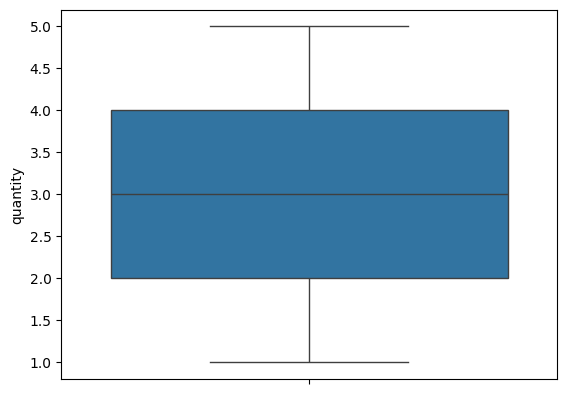

In [57]:
sns.boxplot(data=df2,y='quantity')

<Axes: xlabel='gross_amount', ylabel='Count'>

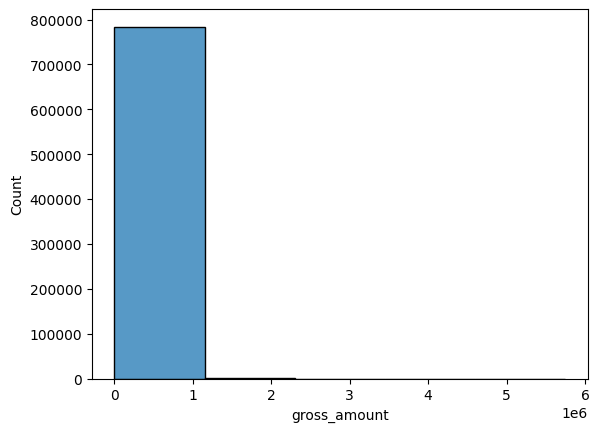

In [58]:
sns.histplot(data=df2,x='gross_amount',bins=5)

<Axes: xlabel='discount_amount', ylabel='Count'>

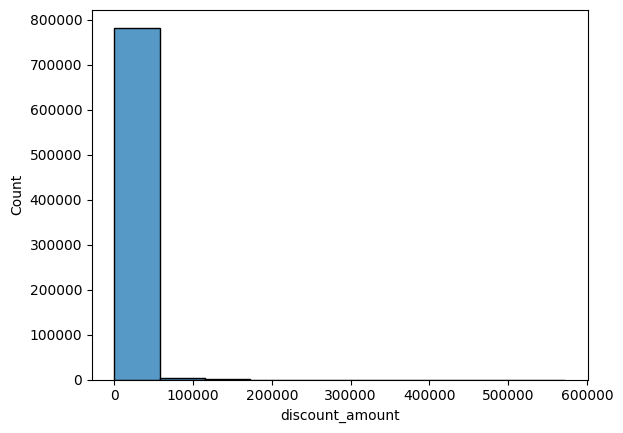

In [59]:
# discount_amount
sns.histplot(data=df2,x='discount_amount',bins=10)


# Bivariate Analysis

- Compare two variables.


In [60]:
category_revenue

,category,net_amount,Revenue_Contribution_%
0,Electronics,1.214500e+10,35.64
1,Music & Instruments,5.419267e+09,15.90
2,Jewellery,5.256486e+09,15.42
3,Office Supplies,3.720655e+09,10.92
4,Gaming,1.438995e+09,4.22
5,Home,1.143510e+09,3.36
6,Footwear,7.762050e+08,2.28
7,Bags & Luggage,7.486150e+08,2.20
8,Sports,6.156641e+08,1.81
9,Automotive,5.497761e+08,1.61


In [61]:
top_categories

,category,net_amount
6,Electronics,1.222135e+10
13,Music & Instruments,5.447600e+09
12,Jewellery,5.276126e+09
14,Office Supplies,3.746905e+09
8,Gaming,1.445363e+09
11,Home,1.150213e+09
7,Footwear,7.801014e+08
2,Bags & Luggage,7.534758e+08
16,Sports,6.198205e+08
0,Automotive,5.527822e+08


<Axes: xlabel='category', ylabel='net_amount'>

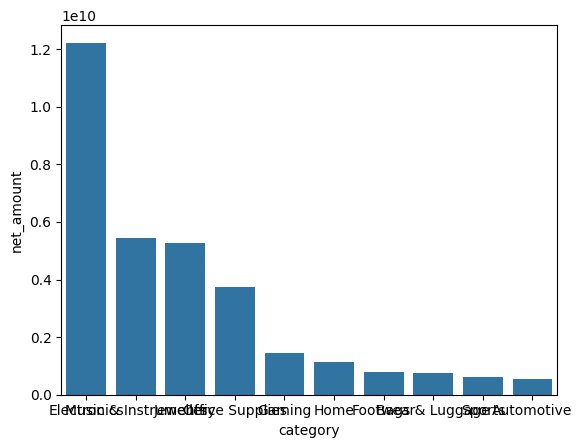

In [62]:
sns.barplot(data=top_categories,x='category',y='net_amount')

In [63]:
top_products_returned=(df2.groupby(['customer_id','first_name'])['return_date']
                       .count()
                       .reset_index(name="return")
                       .sort_values('return',ascending=False)
                       .head(10))
top_products_returned

,customer_id,first_name,return
11009,CUST011012,advik,8
81828,CUST081841,pranay,8
8844,CUST008847,pihu,7
11187,CUST011190,vidur,7
26092,CUST026096,priyansh,7
30604,CUST030608,anika,7
29851,CUST029855,jiya,7
38346,CUST038356,kartik,7
51138,CUST051148,kashvi,7
45103,CUST045113,neysa,7


In [64]:
df2.head(2)

,order_line_id,order_date,customer_id,product_id,category,seller_id,seller_rating,location_id_x,delivery_person_id,payment_id,...,payment_provider,seller_name,delivery_person_name,employment_type,vehicle_type,state,city,postal_code,region,Month
0,OL00000001,2026-02-20,CUST009513,PROD000763,Baby,SELL2379,4.6,LOC0010,DEL01094,PAY005,...,Mastercard,"Virk, Kamdar and Kakar",Bhamini Acharya,Full-Time,Van,Karnataka,Bengaluru,843810,South,2026-02
1,OL00000002,2025-12-02,CUST003412,PROD000142,Clothing,SELL2964,4.0,LOC0053,DEL01927,PAY004,...,Visa,"Chauhan, Bahl and Sem",Emir Roy,Contract,Bike,Madhya Pradesh,Bhopal,406047,Central,2025-12


In [65]:
top_brand=(df2.groupby('brand')['net_amount']
           .sum()
           .reset_index(name='brand_revenue')
           .sort_values('brand_revenue',ascending=False)
           .head(10))
top_brand

,brand,brand_revenue
652,Rolex,2.120465e+09
703,Sony,2.033489e+09
558,Omega,1.095013e+09
669,Samsung,1.092184e+09
419,LG,8.871971e+08
41,Apple,8.476370e+08
837,Yamaha,7.872642e+08
236,Epson,6.505787e+08
536,Nikon,6.453156e+08
580,Panasonic,6.368519e+08


<Axes: xlabel='brand', ylabel='brand_revenue'>

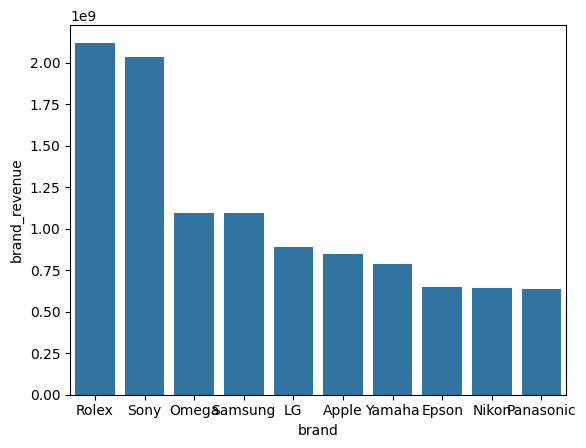

In [66]:
sns.barplot(data=top_brand,x='brand',y='brand_revenue')

In [67]:
top_seller

,seller_id,seller_name,seller_revenue
4127,SELL4128,Chokshi PLC,57433320.11
4416,SELL4417,Shan Ltd,54836797.38
4116,SELL4117,"Keer, Tata and Krishna",54784427.48
2602,SELL2603,Kunda-Kashyap,54564685.23
3275,SELL3276,"Sane, Baria and Mand",54178887.12
3627,SELL3628,Dhawan Inc,53901426.34
3589,SELL3590,"Mandal, Ram and Bhargava",53839238.75
3994,SELL3995,Dugar-Jayaraman,53716005.43
1085,SELL1086,Thakkar-Hegde,53653427.77
3855,SELL3856,"Sarkar, Mann and Babu",53348362.48


<Axes: xlabel='seller_name', ylabel='seller_revenue'>

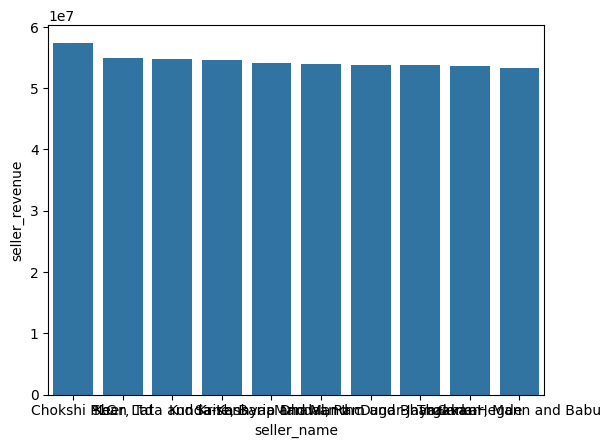

In [68]:
sns.barplot(data=top_seller,x='seller_name',y='seller_revenue')

In [69]:
top_cities=(df2.groupby('city')['net_amount'].sum()
            .reset_index(name="city_revenue")
            .sort_values('city_revenue',ascending=False)
            .head(10))
top_cities

,city,city_revenue
88,Rourkela,3.514760e+08
55,Kolkata,3.489296e+08
104,Tirunelveli,3.457686e+08
105,Tumakuru,3.361229e+08
107,Ujjain,3.345527e+08
91,Salem,3.329762e+08
111,Vellore,3.325145e+08
51,Khammam,3.314249e+08
101,Thrissur,3.312195e+08
9,Aurangabad,3.300814e+08


<Axes: xlabel='city', ylabel='city_revenue'>

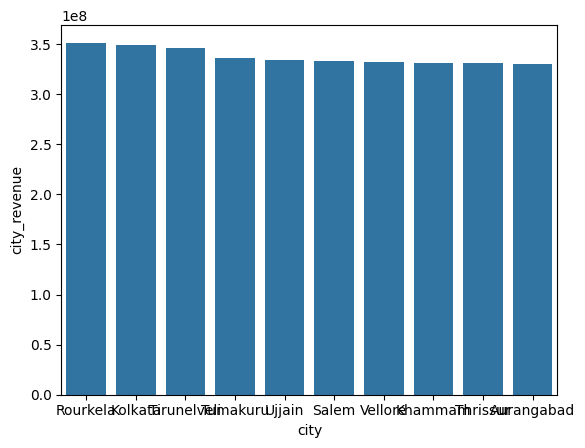

In [70]:
sns.barplot(data=top_cities,x='city',y='city_revenue')

### Does discount increase sales?	discount_amount vs net_amount	Scatter

In [71]:
discount_sales=df2[['discount_amount','net_amount']]

<Axes: xlabel='discount_amount', ylabel='net_amount'>

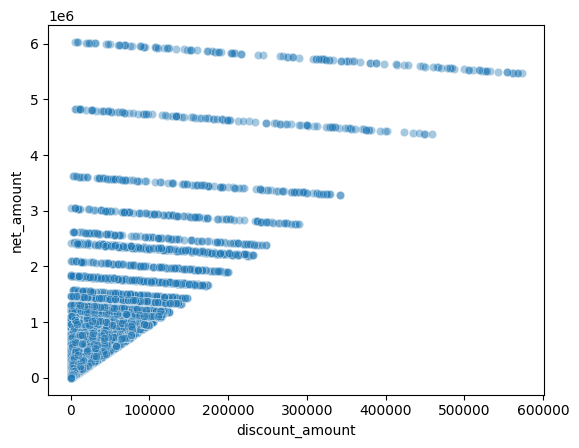

In [72]:
sns.scatterplot(
    data=discount_sales,
    x='discount_amount',
    y='net_amount',
    alpha=0.4
)

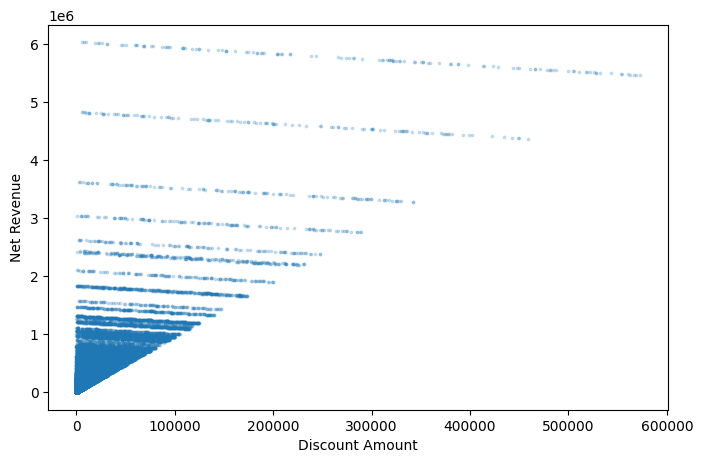

In [73]:
plt.figure(figsize=(8,5))

plt.scatter(
    df2['discount_amount'],
    df2['net_amount'],
    s=3,
    alpha=0.2
)

plt.xlabel("Discount Amount")
plt.ylabel("Net Revenue")
plt.show()

### Does delay affect rating?	delivery_delay_days vs customer_rating	Scatter

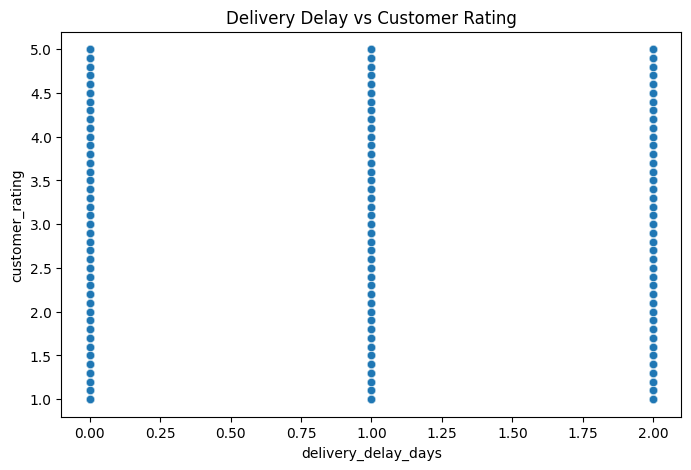

In [74]:
delay_affect_rating = df2[['delivery_delay_days', 'customer_rating']]

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=delay_affect_rating,
    x='delivery_delay_days',
    y='customer_rating',
    alpha=0.5
)
plt.title("Delivery Delay vs Customer Rating")
plt.show()

In [75]:
df2

,order_line_id,order_date,customer_id,product_id,category,seller_id,seller_rating,location_id_x,delivery_person_id,payment_id,...,payment_provider,seller_name,delivery_person_name,employment_type,vehicle_type,state,city,postal_code,region,Month
0,OL00000001,2026-02-20,CUST009513,PROD000763,Baby,SELL2379,4.6,LOC0010,DEL01094,PAY005,...,Mastercard,"Virk, Kamdar and Kakar",Bhamini Acharya,Full-Time,Van,Karnataka,Bengaluru,843810,South,2026-02
1,OL00000002,2025-12-02,CUST003412,PROD000142,Clothing,SELL2964,4.0,LOC0053,DEL01927,PAY004,...,Visa,"Chauhan, Bahl and Sem",Emir Roy,Contract,Bike,Madhya Pradesh,Bhopal,406047,Central,2025-12
2,OL00000003,2025-04-03,CUST065509,PROD001194,Gaming,SELL2485,3.9,LOC0095,DEL00300,PAY009,...,Paytm,Loke-Gupta,Akarsh Bala,Full-Time,EV Bike,Delhi,Dwarka,246344,North,2025-04
3,OL00000004,2025-06-01,CUST070677,PROD000221,Home,SELL4121,4.0,LOC0038,DEL02152,PAY004,...,Visa,Sengupta-D’Alia,Urvi Sabharwal,Contract,Scooter,West Bengal,Kharagpur,705775,East,2025-06
4,OL00000005,2025-10-25,CUST017845,PROD000806,Pets,SELL3183,4.5,LOC0109,DEL03896,PAY012,...,Amazon Pay,Varghese Group,Vivaan Warrior,Full-Time,EV Bike,Haryana,Faridabad,744789,North,2025-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
790727,OL00790728,2025-11-15,CUST073518,PROD001236,Office Supplies,SELL3351,3.7,LOC0093,DEL06036,PAY008,...,Google Pay,Ravel-Wason,Tanya Kari,Contract,Scooter,Punjab,Hoshiarpur,299286,North,2025-11
790728,OL00790729,2025-09-02,CUST027946,PROD000245,Home,SELL0889,4.4,LOC0066,DEL00856,PAY002,...,Mastercard,Zachariah-Thaker,Drishya Bedi,Contract,EV Bike,Kerala,Kannur,831343,South,2025-09
790729,OL00790730,2026-02-07,CUST003703,PROD001217,Office Supplies,SELL1882,2.3,LOC0095,DEL05064,PAY014,...,COD,Kara-Chaudry,Ahana Shetty,Full-Time,Scooter,Delhi,Dwarka,246344,North,2026-02
790730,OL00790731,2025-04-03,CUST004618,PROD000427,Sports,SELL3383,3.6,LOC0066,DEL06494,PAY012,...,Amazon Pay,Ram Group,Samaira Dhaliwal,Full-Time,EV Bike,Kerala,Kannur,831343,South,2025-04


In [76]:
category_returns = (
    df2[df2['return_flag'] == True]
    .groupby('category')['return_flag']
    .count()
    .reset_index(name='total_returns')
    .sort_values('total_returns', ascending=False)
)

category_returns

,category,total_returns
6,Electronics,8144
4,Books,6498
5,Clothing,6482
11,Home,6475
9,Groceries,6441
16,Sports,5656
3,Beauty,5648
1,Baby,5628
18,Toys,5627
12,Jewellery,5607


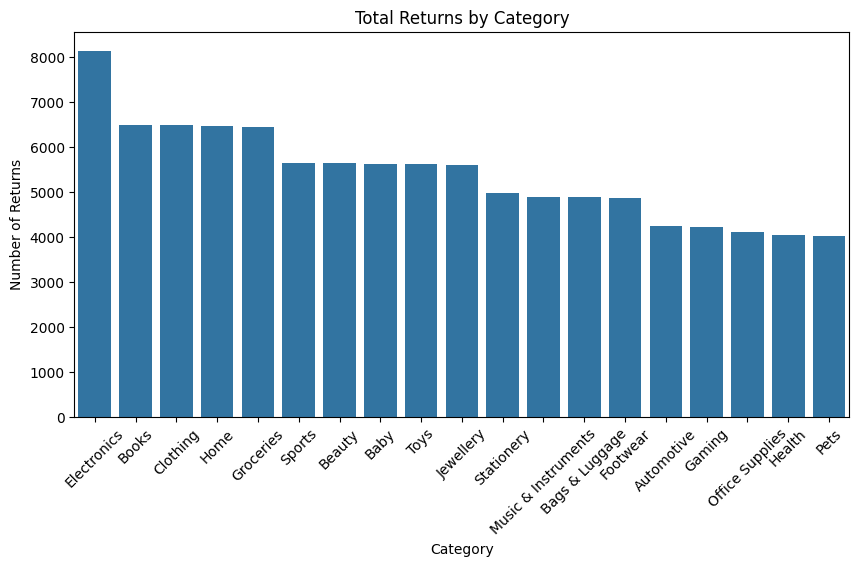

In [77]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=category_returns,
    x='category',
    y='total_returns'
)
plt.xticks(rotation=45)
plt.title("Total Returns by Category")
plt.xlabel("Category")
plt.ylabel("Number of Returns")
plt.show()

In [78]:
seller_delay = (
    df2.groupby('seller_name')['delivery_delay_days']
       .mean()
       .reset_index(name='avg_delay_days')
       .sort_values('avg_delay_days', ascending=False)
)

seller_delay.head(10)

,seller_name,avg_delay_days
2972,"Reddy, Sen and Subramanian",0.650794
3925,"Uppal, Bir and Bhavsar",0.639098
2307,Kothari PLC,0.632479
2965,"Ray, Yohannan and Sibal",0.630435
1809,Hayer PLC,0.628099
3373,"Seshadri, Shenoy and Deo",0.614679
1210,"Desai, Bal and Ray",0.607407
2201,"Khalsa, Agarwal and Hayre",0.606635
380,"Barman, Bhattacharyya and Lata",0.606218
2244,"Khosla, Gola and Varkey",0.600000


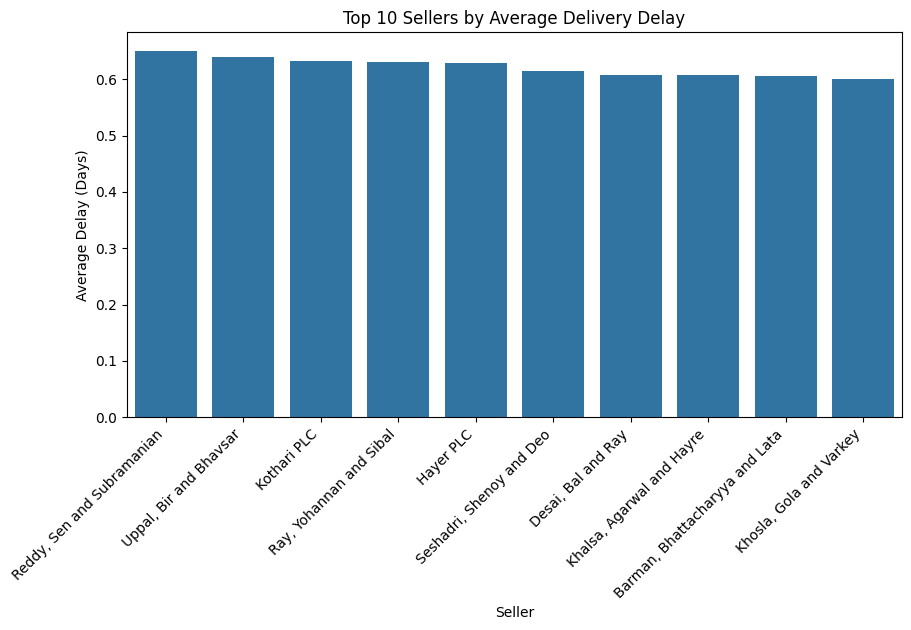

In [79]:
top10_delay = seller_delay.head(10)

plt.figure(figsize=(10,5))
sns.barplot(
    data=top10_delay,
    x='seller_name',
    y='avg_delay_days'
)

plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Sellers by Average Delivery Delay')
plt.xlabel('Seller')
plt.ylabel('Average Delay (Days)')
plt.show()

# Multivariate Analysis

- Study three or more variables.

In [92]:
df2['order_month'] = df2['order_date'].dt.to_period('M').astype(str)

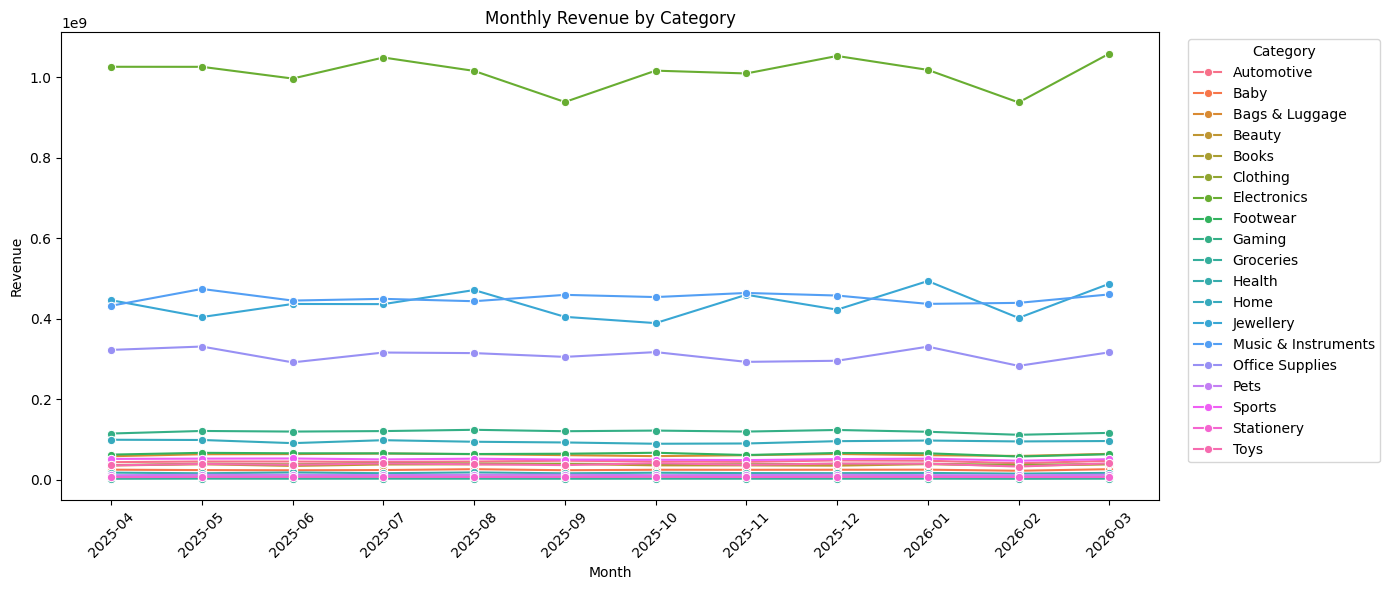

In [95]:
monthly_category_revenue = (
    df2.groupby(['order_month', 'category'])['net_amount']
       .sum()
       .reset_index(name='revenue')
)

plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_category_revenue,
    x='order_month',
    y='revenue',
    hue='category',
    marker='o'
)

plt.title("Monthly Revenue by Category")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend(title="Category", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()